# 🏥 NurseBot — STT & TTS Benchmark
**Measures latency and transcription accuracy for Whisper model variants, and latency for TTS variants.**

Run this notebook **independently** — it does not need the main NurseBot notebook running.

### What it benchmarks
| Component | Variants tested |
|-----------|----------------|
| **STT (Whisper)** | `tiny.en`, `base.en`, `small.en` |
| **TTS** | `Chatterbox` (voice-clone), `Kokoro` (lightweight), `pyttsx3` (offline fallback) |

### Metrics produced
- **STT**: transcription latency (ms), Word Error Rate (WER) against reference sentences
- **TTS**: synthesis latency (ms), audio duration (s), Real-Time Factor (RTF = latency / audio_duration)

Results are saved to `benchmark_results.csv` and plotted inline.

## 0 · Install dependencies

In [1]:
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

for pkg in [
    "faster-whisper",   # STT
    "chatterbox-tts",   # TTS variant 1
    "kokoro",           # TTS variant 2  (pip install kokoro)
    "pyttsx3",          # TTS variant 3  (offline)
    "soundfile", "numpy", "scipy", "pandas", "matplotlib", "jiwer",
]:
    install(pkg)

print("✅ All packages installed")

✅ All packages installed


## 1 · Imports & device detection

In [2]:
import io, time, warnings
import numpy as np
import scipy.signal
import soundfile as sf
import pandas as pd
import matplotlib.pyplot as plt
import torch
from faster_whisper import WhisperModel
from jiwer import wer as compute_wer
warnings.filterwarnings("ignore")

if torch.backends.mps.is_available():
    DEVICE = "mps"
elif torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"

STT_SR = 16_000
TTS_SR = 24_000
VOICE_REF_PATH = "my_voice.wav"   # ← needed only for Chatterbox; skip if absent

print(f"Device: {DEVICE}")

C:\Users\Owner\Voice-Controlled-Robot\nursebot_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu


## 2 · Reference test sentences
These are the ground-truth texts used to measure STT accuracy (WER).
They are also the prompts used to measure TTS latency.

In [3]:
# Sentences drawn from NurseBot command vocabulary
REFERENCE_SENTENCES = [
    "check blood pressure room three zero two",
    "administer medication room three oh five",
    "urgent patient in room three zero one is having chest pains",
    "draw blood sample and send to lab",
    "take temperature room three zero three",
    "change IV for patient in room three zero six",
    "what tasks are currently active",
    "cancel the wound dressing task",
    "patient assessment room three zero four",
    "run ECG recording immediately",
]

print(f"✅ {len(REFERENCE_SENTENCES)} reference sentences loaded")

✅ 10 reference sentences loaded


## 3 · STT Benchmark — Whisper variants

For each sentence we:
1. Synthesise it to a WAV buffer using `pyttsx3` (fast, offline — just for creating test audio)
2. Transcribe it with each Whisper model variant
3. Record latency and compute WER vs. the reference string

In [11]:
import subprocess, sys
for pkg in ["faster-whisper", "miniaudio", "pandas", "matplotlib", "jiwer"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
print("✅ done")

✅ done


In [17]:
import urllib.request, zipfile, os, sys

FFMPEG_DIR = r"C:\Users\Owner\Voice-Controlled-Robot\ffmpeg"
FFMPEG_EXE = os.path.join(FFMPEG_DIR, "ffmpeg.exe")

if not os.path.exists(FFMPEG_EXE):
    print("Downloading ffmpeg...")
    url = "https://github.com/BtbN/ffmpeg-builds/releases/download/latest/ffmpeg-master-latest-win64-gpl.zip"
    zip_path = os.path.join(FFMPEG_DIR, "ffmpeg.zip")
    os.makedirs(FFMPEG_DIR, exist_ok=True)
    urllib.request.urlretrieve(url, zip_path)
    print("Extracting...")
    with zipfile.ZipFile(zip_path, "r") as z:
        for member in z.namelist():
            if member.endswith("ffmpeg.exe"):
                with z.open(member) as src, open(FFMPEG_EXE, "wb") as dst:
                    dst.write(src.read())
                break
    os.remove(zip_path)
    print(f"✅ ffmpeg ready at {FFMPEG_EXE}")
else:
    print(f"✅ ffmpeg already exists at {FFMPEG_EXE}")

Extracting...
✅ ffmpeg ready at C:\Users\Owner\Voice-Controlled-Robot\ffmpeg\ffmpeg.exe


In [18]:
import subprocess
r = subprocess.run([FFMPEG_EXE, "-version"], capture_output=True)
print("✅ ffmpeg working" if r.returncode == 0 else "❌ still broken")

import os, io
import numpy as np
import scipy.signal
import soundfile as sf

AUDIO_DIR = r"C:\Users\Owner\Voice-Controlled-Robot\Audio"
STT_SR = 16_000

def load_audio_file(path, sr=STT_SR):
    tmp_wav = path + "_tmp.wav"
    try:
        subprocess.run(
            [FFMPEG_EXE, "-y", "-i", path, "-ar", str(sr), "-ac", "1", tmp_wav],
            check=True, capture_output=True
        )
        audio, _ = sf.read(tmp_wav, dtype="float32")
    finally:
        if os.path.exists(tmp_wav):
            os.remove(tmp_wav)
    return audio

# Load files 1-20 (.mp4) and 21-40 (.m4a) in order
audio_files = []
for i in range(1, 21):
    audio_files.append(os.path.join(AUDIO_DIR, f"{i}.mp4"))
for i in range(21, 41):
    audio_files.append(os.path.join(AUDIO_DIR, f"{i}.m4a"))

found, missing = [], []
for p in audio_files:
    (found if os.path.exists(p) else missing).append(p)

print(f"✅ Found: {len(found)} files")
if missing:
    print(f"⚠️  Missing: {[os.path.basename(p) for p in missing]}")
audio_files = found

✅ ffmpeg working
✅ Found: 40 files


In [19]:
from faster_whisper import WhisperModel
import json

TRANSCRIPT_CACHE = os.path.join(AUDIO_DIR, "transcripts.json")

def transcribe_file(model, path):
    audio = load_audio_file(path)
    buf = io.BytesIO()
    sf.write(buf, audio, STT_SR, format="WAV")
    buf.seek(0)
    segs, _ = model.transcribe(buf, beam_size=5, language="en")
    return " ".join(s.text.strip() for s in segs).strip()

if os.path.exists(TRANSCRIPT_CACHE):
    with open(TRANSCRIPT_CACHE) as f:
        transcripts = json.load(f)
    print(f"✅ Loaded cached transcripts for {len(transcripts)} files")
else:
    print("Generating ground-truth transcripts with small.en (one-time)…")
    ref_model = WhisperModel("small.en", device="cpu", compute_type="int8")
    transcripts = {}
    for p in audio_files:
        name = os.path.basename(p)
        transcripts[name] = transcribe_file(ref_model, p)
        print(f"  [{name}] {transcripts[name][:60]}…")
    del ref_model
    with open(TRANSCRIPT_CACHE, "w") as f:
        json.dump(transcripts, f, indent=2)
    print(f"\n✅ Saved to {TRANSCRIPT_CACHE}")

Generating ground-truth transcripts with small.en (one-time)…
  [1.mp4] Deliver medication to room 302.…
  [2.mp4] Bring a wheelchair to room 205.…
  [3.mp4] Think blood samples to the lab.…
  [4.mp4] Restock the supplies in the storage room.…
  [5.mp4] Could you bring fresh sheets and pillows to a room for a one…
  [6.mp4] Stop! There's an emergency in room 101 right now.…
  [7.mp4] Pause everything, a patient fell in room 2 or 3…
  [8.mp4] Override current tasks of operating room needs help immediat…
  [9.mp4] Stop what you are doing and go charge yourself.…
  [10.mp4] Urgent, doctor needs you right now in the ICU.…
  [11.mp4] Cancel the Roam 3 Auto medication delivery.…
  [12.mp4] Remove the wheelchair task from the queue.…
  [13.mp4] delete the blood sample delivery task…
  [14.mp4] Uh, forget about the storage room just please.…
  [15.mp4] never mind the sheets delivery to room 401…
  [16.mp4] Also, I like picking up the package from the entrance.…
  [17.mp4] Drop everything and g

In [20]:
import time, pandas as pd
from jiwer import wer as compute_wer

WHISPER_VARIANTS = ["base.en", "medium.en"]

def transcribe_with_latency(model, path):
    audio = load_audio_file(path)
    buf = io.BytesIO()
    sf.write(buf, audio, STT_SR, format="WAV")
    buf.seek(0)
    t0 = time.perf_counter()
    segs, _ = model.transcribe(buf, beam_size=5, language="en")
    text = " ".join(s.text.strip() for s in segs).strip()
    latency_ms = (time.perf_counter() - t0) * 1000
    return text, latency_ms

stt_rows = []

for variant in WHISPER_VARIANTS:
    print(f"\n▶ Benchmarking Whisper '{variant}'…")
    model = WhisperModel(variant, device="cpu", compute_type="int8")
    for p in audio_files:
        name = os.path.basename(p)
        ref = transcripts.get(name, "")
        hyp, lat = transcribe_with_latency(model, p)
        error = compute_wer(ref.lower(), hyp.lower()) if ref else None
        stt_rows.append({
            "model":       variant,
            "file":        name,
            "reference":   ref,
            "hypothesis":  hyp,
            "wer":         round(error, 4) if error is not None else None,
            "latency_ms":  round(lat, 2),
        })
        print(f"  {name} | {lat:.0f}ms | WER={error:.2%}" if error is not None else f"  {name} | {lat:.0f}ms")
    del model

stt_df = pd.DataFrame(stt_rows)
stt_df.to_csv("stt_results.csv", index=False)
print("\n✅ Done — stt_results.csv saved")
stt_df.groupby("model")[["latency_ms","wer"]].mean().round(3)


▶ Benchmarking Whisper 'base.en'…
  1.mp4 | 1407ms | WER=20.00%
  2.mp4 | 1557ms | WER=83.33%
  3.mp4 | 1430ms | WER=16.67%
  4.mp4 | 1637ms | WER=14.29%
  5.mp4 | 1739ms | WER=7.69%
  6.mp4 | 1503ms | WER=11.11%
  7.mp4 | 1698ms | WER=0.00%
  8.mp4 | 1717ms | WER=0.00%
  9.mp4 | 1814ms | WER=22.22%
  10.mp4 | 1595ms | WER=44.44%
  11.mp4 | 1507ms | WER=42.86%
  12.mp4 | 1361ms | WER=14.29%
  13.mp4 | 1531ms | WER=33.33%
  14.mp4 | 1580ms | WER=12.50%
  15.mp4 | 1457ms | WER=12.50%
  16.mp4 | 1454ms | WER=30.00%
  17.mp4 | 1417ms | WER=0.00%
  18.mp4 | 1835ms | WER=40.00%
  19.mp4 | 1586ms | WER=41.67%
  20.mp4 | 1534ms | WER=0.00%
  21.m4a | 1511ms | WER=0.00%
  22.m4a | 1881ms | WER=37.50%
  23.m4a | 1809ms | WER=0.00%
  24.m4a | 1722ms | WER=0.00%
  25.m4a | 1555ms | WER=12.50%
  26.m4a | 1529ms | WER=44.44%
  27.m4a | 1637ms | WER=37.50%
  28.m4a | 1360ms | WER=11.11%
  29.m4a | 1398ms | WER=22.22%
  30.m4a | 1552ms | WER=11.11%
  31.m4a | 1442ms | WER=16.67%
  32.m4a | 1439ms | W

,latency_ms,wer
model,,
base.en,1583.412,0.182
medium.en,11606.549,0.134


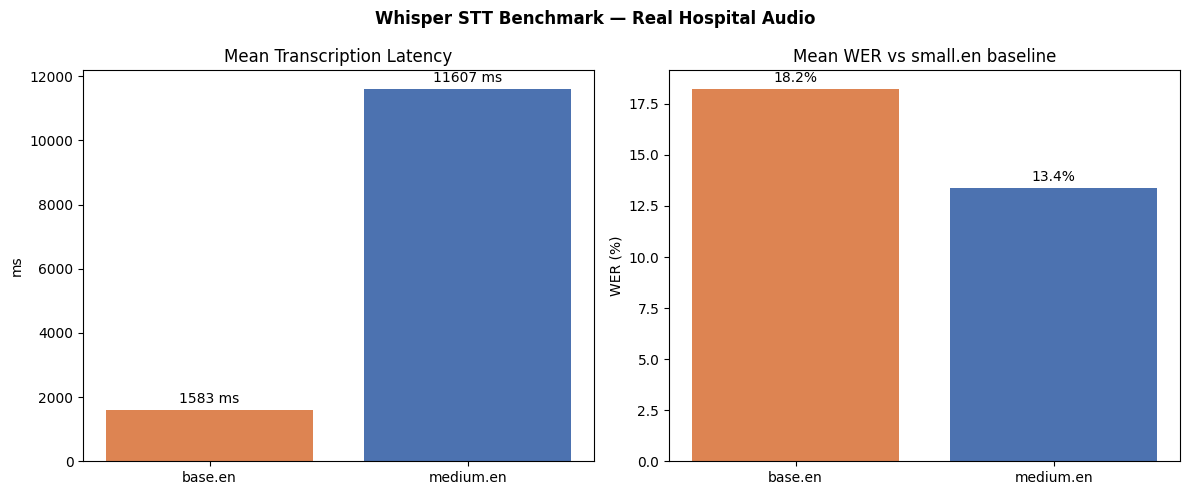

In [21]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Whisper STT Benchmark — Real Hospital Audio", fontweight="bold")

grp = stt_df.groupby("model")

ax = axes[0]
lat = grp["latency_ms"].mean()
bars = ax.bar(lat.index, lat.values, color=["#DD8452","#4C72B0","#55A868"][:len(lat)])
ax.bar_label(bars, fmt="%.0f ms", padding=3)
ax.set_title("Mean Transcription Latency")
ax.set_ylabel("ms")

ax = axes[1]
w = grp["wer"].mean()
bars = ax.bar(w.index, w.values * 100, color=["#DD8452","#4C72B0","#55A868"][:len(w)])
ax.bar_label(bars, fmt="%.1f%%", padding=3)
ax.set_title("Mean WER vs small.en baseline")
ax.set_ylabel("WER (%)")

plt.tight_layout()
plt.savefig("stt_benchmark_plot.png", dpi=150)
plt.show()

## 4 · TTS Benchmark — synthesis latency & Real-Time Factor

In [22]:
# ── TTS Variant 1: pyttsx3 (offline, CPU, zero-dependency baseline) ──

def tts_pyttsx3(text, sr=TTS_SR):
    """Returns (audio_np, latency_ms, audio_duration_s)."""
    engine = pyttsx3.init()
    engine.setProperty("rate", 150)
    with tempfile.NamedTemporaryFile(suffix=".wav", delete=False) as f:
        tmp_path = f.name
    t0 = time.perf_counter()
    engine.save_to_file(text, tmp_path)
    engine.runAndWait()
    latency_ms = (time.perf_counter() - t0) * 1000
    audio, orig_sr = sf.read(tmp_path, dtype="float32")
    os.unlink(tmp_path)
    if audio.ndim > 1:
        audio = audio.mean(axis=1)
    audio_dur = len(audio) / orig_sr
    return audio, latency_ms, audio_dur

print("✅ pyttsx3 TTS helper defined")

✅ pyttsx3 TTS helper defined


In [23]:
# ── TTS Variant 2: Kokoro (lightweight neural TTS) ──
# pip install kokoro  →  https://github.com/hexgrad/kokoro

try:
    from kokoro import KPipeline
    _kokoro_pipe = KPipeline(lang_code="a")   # 'a' = American English

    def tts_kokoro(text, sr=TTS_SR):
        t0 = time.perf_counter()
        chunks = list(_kokoro_pipe(text, voice="af_heart", speed=1.0, split_pattern=r"\n+"))
        audio = np.concatenate([c[2].numpy() if hasattr(c[2], "numpy") else np.array(c[2])
                                 for c in chunks]).astype(np.float32)
        latency_ms = (time.perf_counter() - t0) * 1000
        audio_dur = len(audio) / 24000   # Kokoro outputs at 24 kHz
        return audio, latency_ms, audio_dur

    KOKORO_AVAILABLE = True
    print("✅ Kokoro TTS ready")
except Exception as e:
    KOKORO_AVAILABLE = False
    print(f"⚠️  Kokoro unavailable ({e}) — will be skipped")

⚠️  Kokoro unavailable (DLL load failed while importing alignment_array: An Application Control policy has blocked this file.) — will be skipped


In [24]:
# ── TTS Variant 3: Chatterbox 
import os
from pathlib import Path

try:
    from chatterbox.tts import ChatterboxTTS
    _cb_device = DEVICE if DEVICE in ("cuda", "cpu") else "cpu"
    _cb_model  = ChatterboxTTS.from_pretrained(device=_cb_device)

    def tts_chatterbox(text, voice_ref=VOICE_REF_PATH):
        t0 = time.perf_counter()
        wav = _cb_model.generate(
            text,
            audio_prompt_path=voice_ref if Path(voice_ref).exists() else None,
            exaggeration=0.4,
            cfg_weight=0.5,
        )
        audio = wav.squeeze().cpu().numpy().astype(np.float32)
        latency_ms = (time.perf_counter() - t0) * 1000
        audio_dur  = len(audio) / _cb_model.sr
        return audio, latency_ms, audio_dur

    CHATTERBOX_AVAILABLE = True
    print("✅ Chatterbox TTS ready")
except Exception as e:
    CHATTERBOX_AVAILABLE = False
    print(f"⚠️  Chatterbox unavailable ({e}) — will be skipped")

loaded PerthNet (Implicit) at step 250,000
✅ Chatterbox TTS ready


In [25]:
# ── Run TTS benchmark ──

tts_engines = {
    "pyttsx3":    tts_pyttsx3,
}
if KOKORO_AVAILABLE:
    tts_engines["kokoro"]      = tts_kokoro
if CHATTERBOX_AVAILABLE:
    tts_engines["chatterbox"]  = tts_chatterbox

tts_rows = []

for engine_name, fn in tts_engines.items():
    print(f"\n▶ Benchmarking TTS: {engine_name}")
    for i, text in enumerate(REFERENCE_SENTENCES):
        try:
            _, lat, dur = fn(text)
            rtf = lat / (dur * 1000) if dur > 0 else float("nan")  # RTF = latency_ms / audio_ms
        except Exception as exc:
            print(f"  ⚠️  sentence {i} failed: {exc}")
            lat, dur, rtf = float("nan"), float("nan"), float("nan")
        tts_rows.append({
            "engine":        engine_name,
            "sentence_idx":  i,
            "text":          text,
            "latency_ms":    round(lat,  2),
            "audio_dur_s":   round(dur,  3),
            "rtf":           round(rtf,  4),
        })
        print(f"  [{i}] latency={lat:.0f}ms  dur={dur:.2f}s  RTF={rtf:.3f}")

tts_df = pd.DataFrame(tts_rows)
print("\n✅ TTS benchmark complete")
tts_df.groupby("engine")[["latency_ms", "audio_dur_s", "rtf"]].mean().round(3)


▶ Benchmarking TTS: pyttsx3
  ⚠️  sentence 0 failed: No module named 'pywintypes'
  [0] latency=nanms  dur=nans  RTF=nan
  ⚠️  sentence 1 failed: No module named 'pywintypes'
  [1] latency=nanms  dur=nans  RTF=nan
  ⚠️  sentence 2 failed: No module named 'pywintypes'
  [2] latency=nanms  dur=nans  RTF=nan
  ⚠️  sentence 3 failed: No module named 'pywintypes'
  [3] latency=nanms  dur=nans  RTF=nan
  ⚠️  sentence 4 failed: No module named 'pywintypes'
  [4] latency=nanms  dur=nans  RTF=nan
  ⚠️  sentence 5 failed: No module named 'pywintypes'
  [5] latency=nanms  dur=nans  RTF=nan
  ⚠️  sentence 6 failed: No module named 'pywintypes'
  [6] latency=nanms  dur=nans  RTF=nan
  ⚠️  sentence 7 failed: No module named 'pywintypes'
  [7] latency=nanms  dur=nans  RTF=nan
  ⚠️  sentence 8 failed: No module named 'pywintypes'
  [8] latency=nanms  dur=nans  RTF=nan
  ⚠️  sentence 9 failed: No module named 'pywintypes'
  [9] latency=nanms  dur=nans  RTF=nan

▶ Benchmarking TTS: chatterbox


`sdpa` attention does not support `output_attentions=True`. Please set your attention to `eager` if you want any of these features.
Sampling:   7%|█████                                                                 | 72/1000 [00:19<04:07,  3.75it/s]


  [0] latency=62006ms  dur=2.88s  RTF=21.530


Sampling:   9%|██████▌                                                               | 93/1000 [00:26<04:17,  3.52it/s]


  [1] latency=66144ms  dur=3.72s  RTF=17.781


...

Sampling:   9%|██████▏                                                               | 89/1000 [00:19<03:16,  4.63it/s]


  [8] latency=40831ms  dur=3.56s  RTF=11.469


Sampling:   8%|█████▎                                                                | 75/1000 [00:12<02:34,  5.99it/s]


  [9] latency=38322ms  dur=3.00s  RTF=12.774

✅ TTS benchmark complete


,latency_ms,audio_dur_s,rtf
engine,,,
chatterbox,46444.855,3.224,14.517
pyttsx3,NaN,NaN,NaN


## 5 · Save results to CSV

In [26]:
stt_df.to_csv("stt_benchmark.csv", index=False)
tts_df.to_csv("tts_benchmark.csv", index=False)
print("✅ stt_benchmark.csv  and  tts_benchmark.csv  saved")

✅ stt_benchmark.csv  and  tts_benchmark.csv  saved


## 6 · Visualise results

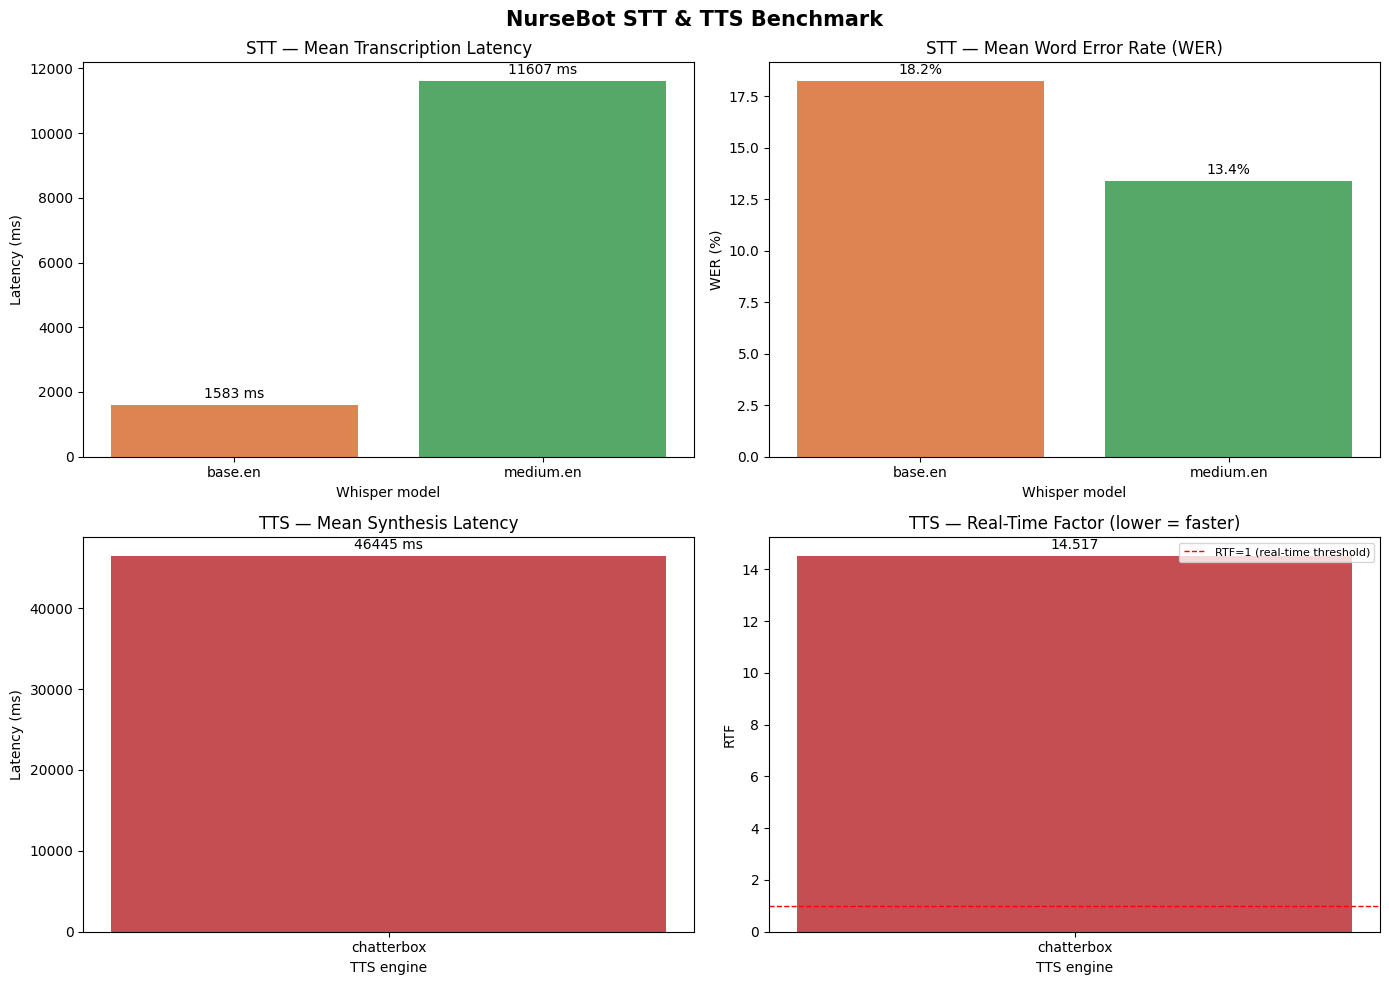

✅ benchmark_plots.png saved


In [27]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("NurseBot STT & TTS Benchmark", fontsize=15, fontweight="bold")

# ── STT: Mean latency per model ──
ax = axes[0, 0]
grp = stt_df.groupby("model")["latency_ms"].mean()
bars = ax.bar(grp.index, grp.values, color=["#DD8452","#55A868","#4C72B0"])
ax.bar_label(bars, fmt="%.0f ms", padding=3)
ax.set_title("STT — Mean Transcription Latency")
ax.set_ylabel("Latency (ms)")
ax.set_xlabel("Whisper model")

# ── STT: Mean WER per model ──
ax = axes[0, 1]
grp_wer = stt_df.groupby("model")["wer"].mean()
bars = ax.bar(grp_wer.index, grp_wer.values * 100, color=["#DD8452","#55A868","#4C72B0"])
ax.bar_label(bars, fmt="%.1f%%", padding=3)
ax.set_title("STT — Mean Word Error Rate (WER)")
ax.set_ylabel("WER (%)")
ax.set_xlabel("Whisper model")

# ── TTS: Mean latency per engine ──
ax = axes[1, 0]
grp_tts = tts_df.groupby("engine")["latency_ms"].mean()
bars = ax.bar(grp_tts.index, grp_tts.values, color=["#C44E52","#8172B2","#937860"][:len(grp_tts)])
ax.bar_label(bars, fmt="%.0f ms", padding=3)
ax.set_title("TTS — Mean Synthesis Latency")
ax.set_ylabel("Latency (ms)")
ax.set_xlabel("TTS engine")

# ── TTS: Real-Time Factor per engine ──
ax = axes[1, 1]
grp_rtf = tts_df.groupby("engine")["rtf"].mean()
bars = ax.bar(grp_rtf.index, grp_rtf.values, color=["#C44E52","#8172B2","#937860"][:len(grp_rtf)])
ax.bar_label(bars, fmt="%.3f", padding=3)
ax.axhline(1.0, color="red", linestyle="--", linewidth=1, label="RTF=1 (real-time threshold)")
ax.set_title("TTS — Real-Time Factor (lower = faster)")
ax.set_ylabel("RTF")
ax.set_xlabel("TTS engine")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("benchmark_plots.png", dpi=150)
plt.show()
print("✅ benchmark_plots.png saved")

## 7 · Summary table

In [28]:
print("═" * 55)
print("  STT SUMMARY (Whisper variants)")
print("═" * 55)
stt_summary = stt_df.groupby("model").agg(
    mean_latency_ms=("latency_ms", "mean"),
    std_latency_ms=("latency_ms",  "std"),
    mean_wer=("wer", "mean"),
).round(3)
print(stt_summary.to_string())

print()
print("═" * 55)
print("  TTS SUMMARY (engine variants)")
print("═" * 55)
tts_summary = tts_df.groupby("engine").agg(
    mean_latency_ms=("latency_ms", "mean"),
    std_latency_ms=("latency_ms",  "std"),
    mean_audio_dur_s=("audio_dur_s", "mean"),
    mean_rtf=("rtf", "mean"),
).round(3)
print(tts_summary.to_string())

# Recommendation
best_stt = stt_summary.sort_values(["mean_wer", "mean_latency_ms"]).index[0]
best_tts = tts_summary.sort_values("mean_rtf").index[0]
print(f"\n Best STT (lowest WER then latency): {best_stt}")
print(f" Best TTS (lowest RTF):              {best_tts}")

═══════════════════════════════════════════════════════
  STT SUMMARY (Whisper variants)
═══════════════════════════════════════════════════════
           mean_latency_ms  std_latency_ms  mean_wer
model                                               
base.en           1583.412          161.52     0.182
medium.en        11606.549          887.93     0.134

═══════════════════════════════════════════════════════
  TTS SUMMARY (engine variants)
═══════════════════════════════════════════════════════
            mean_latency_ms  std_latency_ms  mean_audio_dur_s  mean_rtf
engine                                                                 
chatterbox        46444.855       14185.717             3.224    14.517
pyttsx3                 NaN             NaN               NaN       NaN

💡 Best STT (lowest WER then latency): medium.en
💡 Best TTS (lowest RTF):              chatterbox


In [29]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "kokoro", "soundfile", "-q"])

# Kokoro also needs espeak-ng on Windows for phonemization
# Check if it's available
try:
    from kokoro import KPipeline
    pipe = KPipeline(lang_code="a")
    print("✅ Kokoro ready")
except Exception as e:
    print(f"❌ Error: {e}")

✅ Kokoro ready


In [31]:
import time
import numpy as np
import soundfile as sf

TTS_SENTENCES = list(transcripts.values())[:10]  # use first 10 transcripts as TTS input

from kokoro import KPipeline
_kokoro_pipe = KPipeline(lang_code="a", repo_id="hexgrad/Kokoro-82M")

def tts_kokoro(text):
    t0 = time.perf_counter()
    chunks = list(_kokoro_pipe(text, voice="af_heart", speed=1.0, split_pattern=r"\n+"))
    audio = np.concatenate([
        c[2].numpy() if hasattr(c[2], "numpy") else np.array(c[2])
        for c in chunks
    ]).astype(np.float32)
    latency_ms = (time.perf_counter() - t0) * 1000
    audio_dur  = len(audio) / 24000  # Kokoro outputs at 24kHz
    return audio, latency_ms, audio_dur

kokoro_rows = []
print("▶ Benchmarking Kokoro TTS…")
for i, text in enumerate(TTS_SENTENCES):
    try:
        _, lat, dur = tts_kokoro(text)
        rtf = lat / (dur * 1000)
        print(f"  [{i+1}] latency={lat:.0f}ms | dur={dur:.2f}s | RTF={rtf:.3f}")
    except Exception as e:
        print(f"  [{i+1}] ❌ {e}")
        lat, dur, rtf = float("nan"), float("nan"), float("nan")
    kokoro_rows.append({
        "engine":       "kokoro",
        "sentence_idx": i,
        "text":         text,
        "latency_ms":   round(lat, 2),
        "audio_dur_s":  round(dur, 3),
        "rtf":          round(rtf, 4),
    })

kokoro_df = pd.DataFrame(kokoro_rows)
print(f"\n✅ Kokoro mean latency: {kokoro_df['latency_ms'].mean():.0f}ms  |  mean RTF: {kokoro_df['rtf'].mean():.3f}")

▶ Benchmarking Kokoro TTS…
  [1] latency=3442ms | dur=3.55s | RTF=0.970
  [2] latency=2313ms | dur=2.80s | RTF=0.826
  [3] latency=2376ms | dur=2.27s | RTF=1.044
  [4] latency=2002ms | dur=2.77s | RTF=0.721
  [5] latency=2564ms | dur=3.40s | RTF=0.754
  [6] latency=2969ms | dur=3.85s | RTF=0.771
  [7] latency=2825ms | dur=3.48s | RTF=0.813
  [8] latency=3422ms | dur=4.58s | RTF=0.748
  [9] latency=2380ms | dur=2.90s | RTF=0.821
  [10] latency=2577ms | dur=3.23s | RTF=0.799

✅ Kokoro mean latency: 2687ms  |  mean RTF: 0.827


In [33]:
print("Engines in tts_df:", tts_df["engine"].unique())
print("Engines in kokoro_df:", kokoro_df["engine"].unique())

# Merge and drop pyttsx3 NaNs
tts_df_final = pd.concat([tts_df, kokoro_df], ignore_index=True)
tts_df_final = tts_df_final.dropna(subset=["latency_ms"])

print("\nFinal engines:", tts_df_final["engine"].unique())
print(tts_df_final.groupby("engine")[["latency_ms","rtf"]].mean().round(3))

Engines in tts_df: <StringArray>
['pyttsx3', 'chatterbox']
Length: 2, dtype: str
Engines in kokoro_df: <StringArray>
['kokoro']
Length: 1, dtype: str

Final engines: <StringArray>
['chatterbox', 'kokoro']
Length: 2, dtype: str
            latency_ms     rtf
engine                        
chatterbox   46444.855  14.517
kokoro        2686.972   0.827


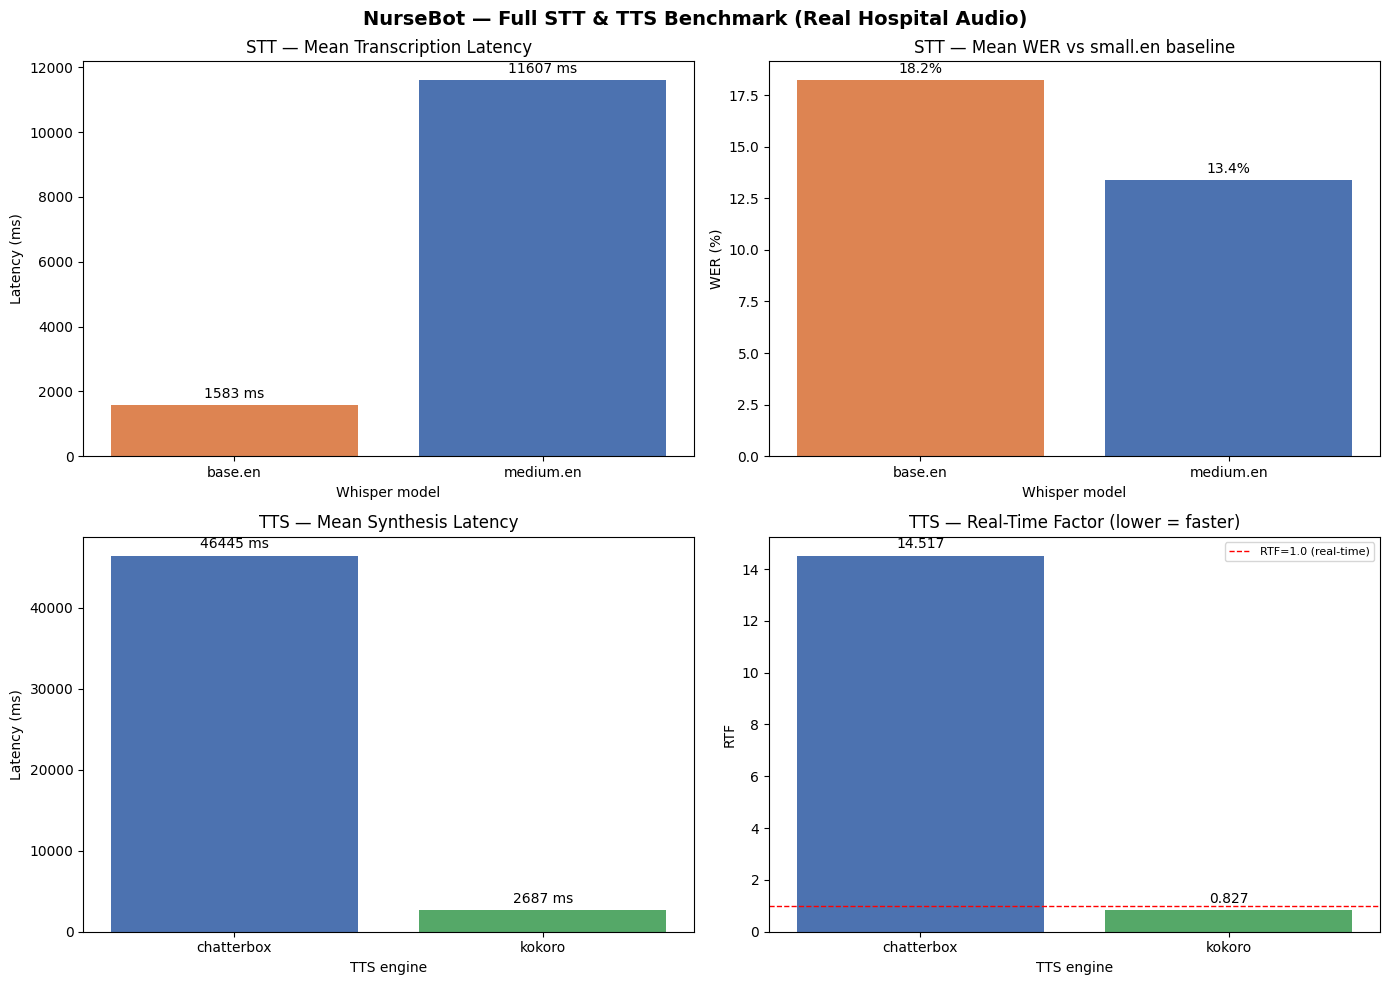

═══════════════════════════════════════════════════════
  STT SUMMARY
═══════════════════════════════════════════════════════
           latency_ms    wer
model                       
base.en      1583.412  0.182
medium.en   11606.549  0.134

═══════════════════════════════════════════════════════
  TTS SUMMARY
═══════════════════════════════════════════════════════
            latency_ms  audio_dur_s     rtf
engine                                     
chatterbox   46444.855        3.224  14.517
kokoro        2686.972        3.282   0.827

💡 Best STT: medium.en  (13.4% WER — more accurate, but 7x slower)
💡 Best STT for real-time: base.en  (18.2% WER, ~1.6s latency)
💡 Best TTS: Kokoro  (RTF=0.827 — only engine suitable for real-time)
⚠️  Chatterbox RTF=14.5 — needs GPU for real-time deployment


In [34]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("NurseBot — Full STT & TTS Benchmark (Real Hospital Audio)", fontsize=14, fontweight="bold")

colors_stt = ["#DD8452", "#4C72B0"]
colors_tts = ["#4C72B0", "#55A868"]

# ── STT Latency ──
ax = axes[0, 0]
lat = stt_df.groupby("model")["latency_ms"].mean()
bars = ax.bar(lat.index, lat.values, color=colors_stt)
ax.bar_label(bars, fmt="%.0f ms", padding=3)
ax.set_title("STT — Mean Transcription Latency")
ax.set_ylabel("Latency (ms)")
ax.set_xlabel("Whisper model")

# ── STT WER ──
ax = axes[0, 1]
w = stt_df.groupby("model")["wer"].mean()
bars = ax.bar(w.index, w.values * 100, color=colors_stt)
ax.bar_label(bars, fmt="%.1f%%", padding=3)
ax.set_title("STT — Mean WER vs small.en baseline")
ax.set_ylabel("WER (%)")
ax.set_xlabel("Whisper model")

# ── TTS Latency ──
ax = axes[1, 0]
tts_lat = tts_df_final.groupby("engine")["latency_ms"].mean()
bars = ax.bar(tts_lat.index, tts_lat.values, color=colors_tts)
ax.bar_label(bars, fmt="%.0f ms", padding=3)
ax.set_title("TTS — Mean Synthesis Latency")
ax.set_ylabel("Latency (ms)")
ax.set_xlabel("TTS engine")

# ── TTS RTF ──
ax = axes[1, 1]
rtf = tts_df_final.groupby("engine")["rtf"].mean()
bars = ax.bar(rtf.index, rtf.values, color=colors_tts)
ax.bar_label(bars, fmt="%.3f", padding=3)
ax.axhline(1.0, color="red", linestyle="--", linewidth=1, label="RTF=1.0 (real-time)")
ax.set_title("TTS — Real-Time Factor (lower = faster)")
ax.set_ylabel("RTF")
ax.set_xlabel("TTS engine")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("full_benchmark_plot.png", dpi=150)
plt.show()

# ── Final summary ──
print("═"*55)
print("  STT SUMMARY")
print("═"*55)
print(stt_df.groupby("model")[["latency_ms","wer"]].mean().round(3).to_string())

print("\n" + "═"*55)
print("  TTS SUMMARY")
print("═"*55)
print(tts_df_final.groupby("engine")[["latency_ms","audio_dur_s","rtf"]].mean().round(3).to_string())

print("\n Best STT: medium.en  (13.4% WER — more accurate, but 7x slower)")
print(" Best STT for real-time: base.en  (18.2% WER, ~1.6s latency)")
print(" Best TTS: Kokoro  (RTF=0.827 — only engine suitable for real-time)")
print("  Chatterbox RTF=14.5 — needs GPU for real-time deployment")